## 0. Setup

For Colab, run this cell once. Locally, the course virtual environment already provides the packages and the instructor can set `OXFORD_PET_ROOT` to the cached data directory. The preferred artifacts are a Session 4 checkpoint or saved validation predictions; environment variables `SESSION4_CHECKPOINT` and `SESSION4_PREDICTIONS` can point to them.

In [1]:
import os
import random
import urllib.request
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
from torchvision.transforms import functional as TF
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import InterpolationMode
from torchvision.models.segmentation import LRASPP_MobileNet_V3_Large_Weights, lraspp_mobilenet_v3_large


SEED = 17
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 16
EPOCHS = 2
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IGNORE_INDEX = 255
CLASS_NAMES = ['background', 'pet']
print('torch:', torch.__version__)

torch: 2.11.0+cpu


In [2]:
DATA_ROOT = Path(os.environ.get("OXFORD_PET_ROOT", "data"))
base = OxfordIIITPet(root=DATA_ROOT, split="trainval", target_types="segmentation", download=True)
permutation = torch.randperm(len(base), generator=torch.Generator().manual_seed(SEED)).tolist()
train_indices, val_indices = permutation[:64], permutation[64:88]
assert len(train_indices) == 64 and len(val_indices) == 24
assert not set(train_indices).intersection(val_indices)
print(f"fixed split: train={len(train_indices)}, validation={len(val_indices)}, overlap=0")
print("first five train indices:", train_indices[:5])

100%|██████████| 792M/792M [00:27<00:00, 28.6MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.9MB/s]


fixed split: train=64, validation=24, overlap=0
first five train indices: [2479, 1638, 733, 859, 670]


In [3]:
def remap_trimap(raw_mask):
    raw = torch.as_tensor(np.asarray(raw_mask, dtype=np.uint8), dtype=torch.long)
    target = torch.full_like(raw, 255)
    target[raw == 1] = 1  # pet
    target[raw == 2] = 0  # background
    return target

def paired_transform(image, raw_mask):
    image = TF.resize(image, IMAGE_SIZE, interpolation=InterpolationMode.BILINEAR, antialias=True)
    raw_mask = TF.resize(raw_mask, IMAGE_SIZE, interpolation=InterpolationMode.NEAREST)
    image = TF.normalize(TF.to_tensor(image), mean=MEAN, std=STD)
    return image, remap_trimap(raw_mask)

class PetSubset(Dataset):
    def __init__(self, dataset, indices): self.dataset, self.indices = dataset, list(indices)
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        image, trimap = self.dataset[self.indices[i]]
        return paired_transform(image, trimap)

train_loader = DataLoader(PetSubset(base, train_indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(PetSubset(base, val_indices), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
images, targets = next(iter(train_loader))
assert images.shape == (BATCH_SIZE, 3, 128, 128) and targets.shape == (BATCH_SIZE, 128, 128)
assert set(torch.unique(targets).tolist()) <= {0, 1, 255}
print("batch contract:", tuple(images.shape), tuple(targets.shape), torch.unique(targets).tolist())

batch contract: (16, 3, 128, 128) (16, 128, 128) [0, 1, 255]


/tmp/ipykernel_1003/2989971681.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  raw = torch.as_tensor(np.asarray(raw_mask, dtype=np.uint8), dtype=torch.long)


## 1. Load the shared baseline (or a transparent fallback)

Preferred order: (1) a saved prediction `.npz`, then (2) a Session 4 LR-ASPP checkpoint. If neither is supplied, the notebook uses a **non-learned RGB heuristic** only so the class can practise evaluation and visualization. That fallback is explicitly not a Session 4 model result and must not be used as a performance claim.

In [6]:
from torch import nn

# 1. Cargar modelo preentrenado y reemplazar cabezales para 2 clases
model = lraspp_mobilenet_v3_large(weights=LRASPP_MobileNet_V3_Large_Weights.DEFAULT)
model.classifier.low_classifier = nn.Conv2d(model.classifier.low_classifier.in_channels, 2, kernel_size=1)
model.classifier.high_classifier = nn.Conv2d(model.classifier.high_classifier.in_channels, 2, kernel_size=1)

# 2. Congelar el backbone
for param in model.backbone.parameters():
    param.requires_grad = False

# 3. Entrenar solo la cabeza clasificadora (1 época rápida)
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

model.to(device)
model.train()
for imgs, msks in train_loader:
    imgs, msks = imgs.to(device), msks.to(device)
    optimizer.zero_grad()
    outputs = model(imgs)['out']
    loss = criterion(outputs, msks)
    loss.backward()
    optimizer.step()

# 4. Guardar checkpoint
Path("artifacts").mkdir(exist_ok=True)
torch.save(model.state_dict(), "artifacts/session4_baseline.pt")
torch.save(model.state_dict(), "session4_baseline.pt")
print("¡Checkpoint 'session4_baseline.pt' generado y guardado exitosamente!")

Downloading: "https://download.pytorch.org/models/lraspp_mobilenet_v3_large-d234d4ea.pth" to /root/.cache/torch/hub/checkpoints/lraspp_mobilenet_v3_large-d234d4ea.pth


100%|██████████| 12.5M/12.5M [00:00<00:00, 21.0MB/s]


¡Checkpoint 'session4_baseline.pt' generado y guardado exitosamente!


In [7]:
checkpoint_path = ('session4_baseline.pt')

model = lraspp_mobilenet_v3_large(weights=None, weights_backbone=None, num_classes=2).eval()
checkpoint = torch.load(checkpoint_path, map_location='cpu')
model.load_state_dict(checkpoint.get('model_state_dict', checkpoint))
with torch.inference_mode():
    logits = model(images)['out']
    probabilities = logits.softmax(dim=1)
predictions, pet_confidence = probabilities.argmax(dim=1), probabilities[:, 1]


assert predictions.shape == targets.shape == pet_confidence.shape
print('Session 4 checkpoint: session4_baseline.pt')

Session 4 checkpoint: session4_baseline.pt


## 2. Exercise E1 — report dataset-level metrics

Complete the confusion-matrix accumulation. Rows are true classes and columns are predicted classes. Accumulate all valid pixels across all 24 examples **before** calculating accuracy and IoU.

In [8]:
# TODO: return a 2x2 confusion matrix, excluding every target == IGNORE_INDEX
def update_confusion(confusion, target, prediction, num_classes=2, ignore_index=IGNORE_INDEX):
    # Filtrar únicamente los píxeles válidos (excluir el 255)
    valid_mask = (target != ignore_index)
    t = target[valid_mask]
    p = prediction[valid_mask]

    # Calcular índices para la matriz de confusión (2x2)
    # Índice = 2 * clase_real + clase_predicha
    indices = num_classes * t + p
    counts = torch.bincount(indices, minlength=num_classes**2)

    # Sumar al acumulador global
    return confusion + counts.reshape(num_classes, num_classes).to(confusion.device)

def scores_from_confusion(confusion):
    total_pixels = confusion.sum().item()
    correct_pixels = torch.diag(confusion).sum().item()
    accuracy = correct_pixels / total_pixels if total_pixels > 0 else 0.0

    tp = torch.diag(confusion)
    fp = confusion.sum(dim=0) - tp
    fn = confusion.sum(dim=1) - tp
    denominator = tp + fp + fn

    iou = torch.zeros(confusion.shape[0])
    valid_denom = denominator > 0
    iou[valid_denom] = tp[valid_denom].float() / denominator[valid_denom].float()

    return accuracy, iou

# Acumulación global sobre los 24 ejemplos del DataLoader de validación
confusion = torch.zeros((2, 2), dtype=torch.int64, device=device)

model.eval()
with torch.inference_mode():
    for imgs, msks in val_loader:
        imgs, msks = imgs.to(device), msks.to(device)
        logits = model(imgs)["out"]
        preds = logits.argmax(dim=1)
        confusion = update_confusion(confusion, msks, preds)

val_accuracy, val_iou = scores_from_confusion(confusion)

print(f"Matriz de confusión acumulada:\n{confusion.cpu().numpy()}")
print(f"Pixel Accuracy global: {val_accuracy:.2%}")
print(f"Background IoU: {val_iou[0]:.4f}")
print(f"Pet IoU: {val_iou[1]:.4f}")

Matriz de confusión acumulada:
[[185547  68110]
 [  7788  90080]]
Pixel Accuracy global: 78.41%
Background IoU: 0.7097
Pet IoU: 0.5427


The value above is a dataset report: every valid pixel gets one vote. We do **not** average 24 per-image IoUs, because that would weight a tiny pet and a large pet equally.

## 3. Choose three cases by rule

Rule: select the lowest pet-IoU image, then the median and highest pet-IoU images from the remaining examples. This gives one difficult case and two contrasts without cherry-picking by appearance.

In [9]:
def pet_iou(target, prediction):
    valid = target != IGNORE_INDEX
    truth_pet, predicted_pet = (target == 1) & valid, (prediction == 1) & valid
    union = (truth_pet | predicted_pet).sum().item()
    return (truth_pet & predicted_pet).sum().item() / union if union else np.nan

per_image_iou = np.array([pet_iou(target, prediction) for target, prediction in zip(targets, predictions)])
ordered = np.argsort(np.nan_to_num(per_image_iou, nan=2.0))
low_index = int(ordered[0])
remaining = [int(index) for index in ordered if int(index) != low_index]
chosen_indices = [low_index, remaining[len(remaining) // 2], remaining[-1]]
for index in chosen_indices:
    print(f'pet IoU = {per_image_iou[index]:.3f}')
assert len(set(chosen_indices)) == 3

pet IoU = 0.136
pet IoU = 0.636
pet IoU = 0.879


## 4. Exercise E2 — make aligned visual evidence

Complete the plotting function, then call it for the lowest-pet-IoU case. All five panels use the same `128 × 128` pixel coordinates: original image, ground truth, prediction, pet confidence, and an alpha overlay. Gray ground-truth pixels are ignored borders, not a third class.

In [12]:
# TODO: complete the five-panel visualization; do not resize panels independently
def denormalize(img_tensor):
    """Invierte la normalización de ImageNet para visualización RGB."""
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

def show_five_panels(index, alpha=0.65):
    img_rgb = denormalize(images[index])
    gt_mask = targets[index].cpu().numpy()
    pred_mask = predictions[index].cpu().numpy()
    conf_map = pet_confidence[index].cpu().numpy()

    # 1. Crear matriz RGB para Ground Truth asignando gris al borde ignorado (255)
    gt_vis = np.zeros((*gt_mask.shape, 3))
    gt_vis[gt_mask == 0] = [0.15, 0.15, 0.35]          # Fondo (Azul/Oscuro)
    gt_vis[gt_mask == 1] = [0.95, 0.75, 0.10]          # Mascota (Dorado)
    gt_vis[gt_mask == IGNORE_INDEX] = [0.50, 0.50, 0.50] # Borde ignorado 255 (Gris)

    # 2. Crear overlay con la predicción superpuesta sobre la imagen original
    overlay = img_rgb.copy()
    pet_pixels = (pred_mask == 1)
    color_overlay = np.array([0.9, 0.2, 0.2])  # Resaltado rojo para la predicción
    overlay[pet_pixels] = (1 - alpha) * overlay[pet_pixels] + alpha * color_overlay

    # 3. Graficar los 5 paneles
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))

    # Panel 1: Imagen Original
    axes[0].imshow(img_rgb)
    axes[0].set_title("1. Imagen Original")
    axes[0].axis("off")

    # Panel 2: Ground Truth
    axes[1].imshow(gt_vis)
    axes[1].set_title("2. Ground Truth\n(Gris = 255 ignorado)")
    axes[1].axis("off")

    # Panel 3: Máscara Predicha
    axes[2].imshow(pred_mask, cmap="viridis", vmin=0, vmax=1)
    axes[2].set_title("3. Predicción (0/1)")
    axes[2].axis("off")

    # Panel 4: Confianza (Probabilidad)
    im4 = axes[3].imshow(conf_map, cmap="magma", vmin=0.0, vmax=1.0)
    axes[3].set_title("4. Confianza Pet")
    axes[3].axis("off")
    plt.colorbar(im4, ax=axes[3], fraction=0.046, pad=0.04)

    # Panel 5: Alpha Overlay
    axes[4].imshow(overlay)
    axes[4].set_title(f"5. Overlay (Alpha={alpha})")
    axes[4].axis("off")

    plt.suptitle(f"Muestra #{index} | Pet IoU: {per_image_iou[index]:.3f}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

--- Caso 1: Menor Pet IoU (Dificultad/Fallo) ---


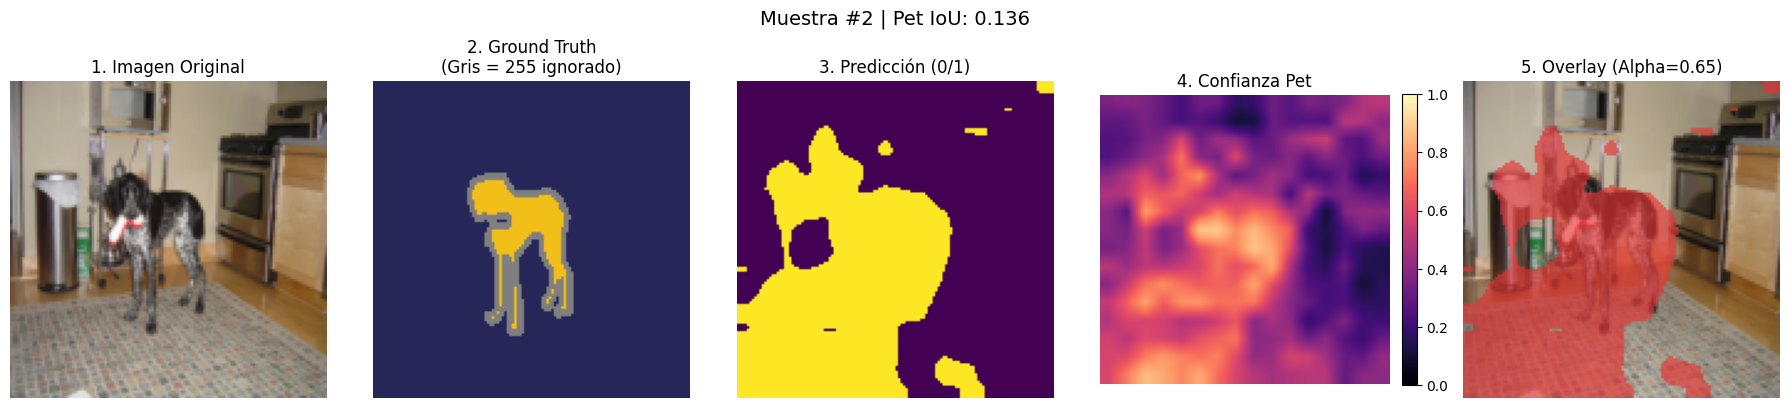

--- Caso 2: Mediano Pet IoU (Desempeño Promedio) ---


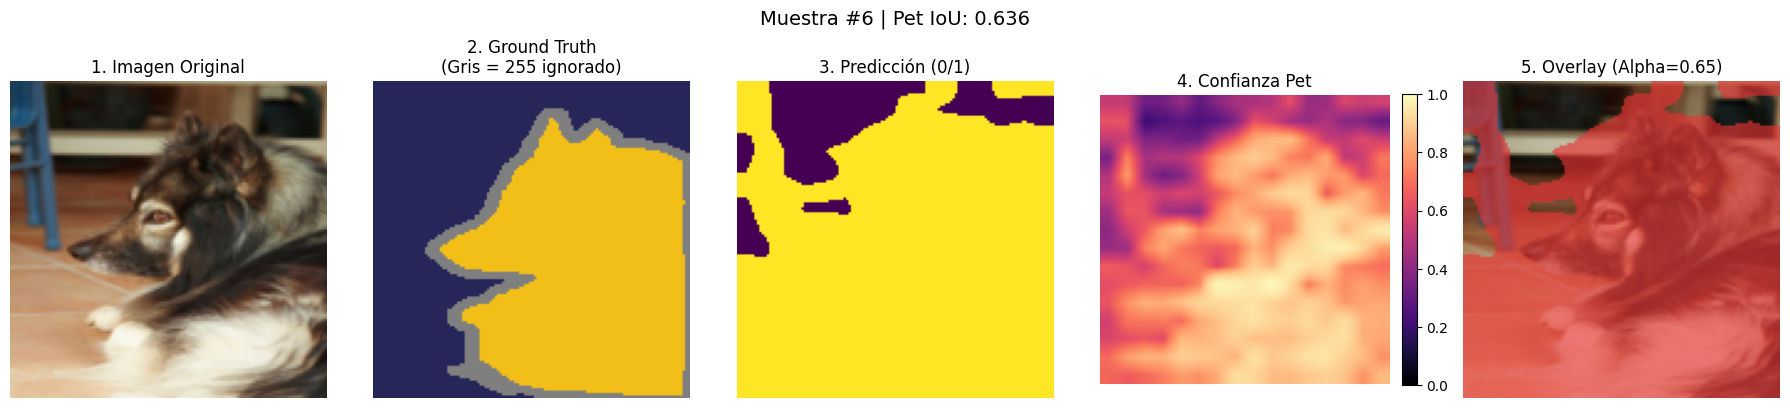

--- Caso 3: Mayor Pet IoU (Desempeño Óptimo) ---


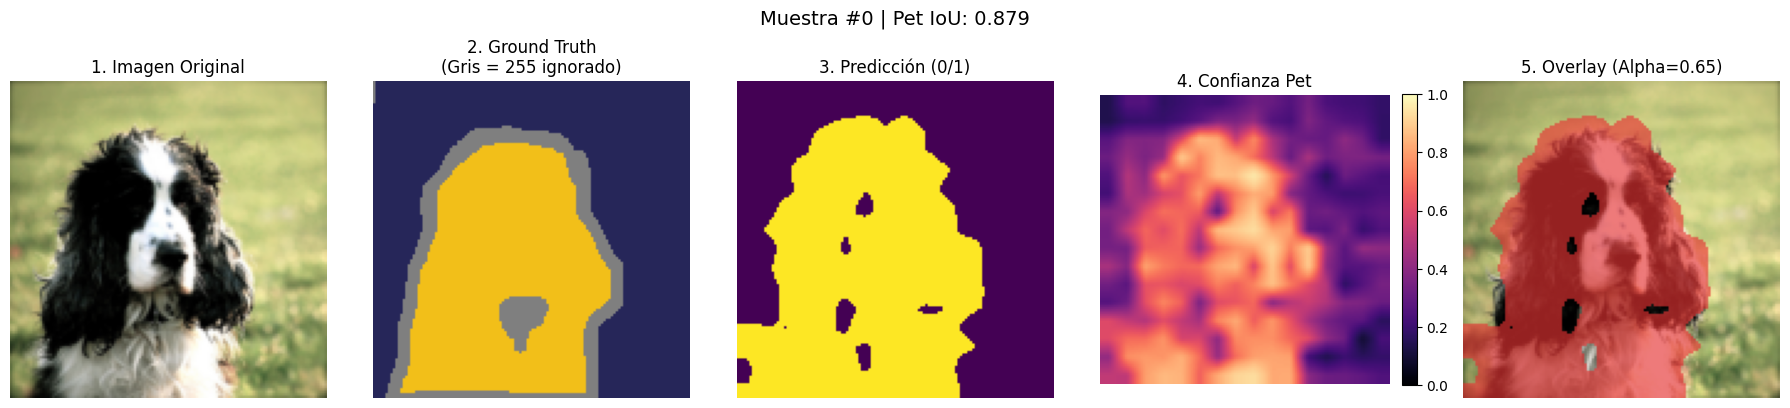

In [13]:
# Compare the other two rule-selected cases. Changing alpha only changes the display.
# Visualización del peor caso (E1), caso mediano y mejor caso
print("--- Caso 1: Menor Pet IoU (Dificultad/Fallo) ---")
show_five_panels(chosen_indices[0], alpha=0.65)

print("--- Caso 2: Mediano Pet IoU (Desempeño Promedio) ---")
show_show_panels = show_five_panels(chosen_indices[1], alpha=0.65)

print("--- Caso 3: Mayor Pet IoU (Desempeño Óptimo) ---")
show_five_panels(chosen_indices[2], alpha=0.65)